# Day 07 — Fine-tune vs RAG vs Prompt

**A decision you will make on every LLM project: where does the missing capability go —
into the prompt, into retrieved context, or into the weights?**

We build one task, attack it three ways with models we fully control, and compare on the five
axes that actually decide it: **accuracy, cost per call, latency, freshness, and build effort.**

## Agenda (60 min)

| # | Segment | Time |
| - | ------- | ---- |
| 0 | The three places knowledge/behaviour can live | 4 min |
| 1 | The task + a controllable model | 8 min |
| 2 | Attack 1 — prompt engineering | 9 min |
| 3 | Attack 2 — RAG (retrieve into context) | 13 min |
| 4 | Attack 3 — fine-tuning (move it into weights) | 13 min |
| 5 | The five-axis comparison + decision rules | 8 min |
| 6 | Exercises + quiz | 5 min |

Kernel: **Python (ai-upskill)**.

In [1]:
import numpy as np, time, textwrap
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)
print("ready")

ready


## 0 — Three places a capability can live (4 min)

| Where | Mechanism | Good for | Bad at |
| ----- | --------- | -------- | ------ |
| **Prompt** | instructions + examples in context every call | format, tone, simple rules, common tasks | new facts, new skills, long instructions (token cost) |
| **RAG** | embed a knowledge base, retrieve top-k, put in context | large/changing factual knowledge, citations, per-user data | teaching *behaviour*/style, latency of retrieval, chunking quality |
| **Fine-tune** | gradient-update the weights on task data | consistent behaviour/skill/format at scale, short prompts | facts that change often (staleness), needs labeled data + training infra |

Mental model: **prompt = working memory, RAG = an open book on the desk, fine-tune = what you
learned in school.** Most production systems use two or three together.

## 1 — The task and a controllable model (8 min)

Task: answer short questions about a fictional company "Cirrus" from its handbook, and always
answer in a fixed house style (`"Per policy §X: <answer>."`). This mixes a **knowledge**
problem (the handbook facts) with a **behaviour** problem (the house style) — so the three
approaches will each shine on a different part.

Our "LLM" is a retrieval-based next-answer predictor over a training memory. It has:
- a `world` it was "pretrained" on (generic office knowledge),
- no knowledge of Cirrus unless we give it some,
- a weak default style.

In [2]:
# ---- the fictional knowledge base ----
HANDBOOK = {
  "vacation":  ("§4.1", "Full-time employees accrue 1.75 vacation days per month, max 30 days carryover."),
  "expenses":  ("§7.2", "Expenses under $75 need no receipt; over $75 require a receipt within 14 days."),
  "remote":    ("§2.3", "Employees may work remote up to 3 days per week with manager approval."),
  "security":  ("§9.5", "Laptops must be full-disk encrypted and locked after 5 minutes idle."),
  "probation": ("§1.4", "New hires are on a 90-day probation period with a 30-day check-in."),
  "referral":  ("§5.6", "Referral bonus is $2,000, paid after the referred hire completes probation."),
}

#                question                                  topic       gold fragment
QUESTIONS = [
  ("how many vacation days do I accrue per month?", "vacation", "1.75"),
  ("do I need a receipt for a $40 lunch?",           "expenses", "$75"),
  ("can I work from home 4 days a week?",            "remote",   "3 days per week"),
  ("how long is the probation period?",              "probation","90-day"),
  ("what is the referral bonus?",                    "referral", "$2,000"),
  ("when must my laptop lock?",                      "security", "5 minutes"),
]
# Grading: an answer is correct iff it (a) starts with the house style "Per policy" AND
# (b) contains the gold fragment from the *real* handbook fact. Generic knowledge never
# contains the fragment, so this cleanly separates "grounded on the right fact" from "guessed".

# ---- the base "model": generic knowledge, weak style ----
GENERIC = {
  "vacation": "Most companies give around 15-20 vacation days per year.",
  "expenses": "Usually you should keep receipts for business expenses.",
  "remote":   "Remote work policies vary; many allow a few days a week.",
  "probation":"Probation periods are often 3 to 6 months.",
  "referral": "Referral bonuses are commonly between $1,000 and $5,000.",
  "security": "Company laptops usually must be encrypted and password protected.",
}

def base_model(system, user, memory=None):
    # memory: optional list of text chunks injected into context (RAG) or a fine-tuned
    # style/fact table. Returns (answer_text, latency_s).
    t0 = time.perf_counter()
    topic = None                       # crude topic detection
    for t in HANDBOOK:
        if t in user: topic = t
    if topic is None:
        for q,tt,_ in QUESTIONS:
            if q == user: topic = tt
    ans = GENERIC.get(topic, "I'm not sure.")
    # if context memory contains the handbook fact, use it
    if memory:
        for chunk in memory:
            if topic and topic in chunk:
                ans = chunk.split("::")[-1].strip()
    # style: only apply house style if system prompt or fine-tune asked for it
    styled = ans
    sec = HANDBOOK.get(topic, ("§?", ""))[0]
    if system and "Per policy" in system:
        styled = f"Per policy {sec}: {ans}"
    time.sleep(0.001)
    return styled, time.perf_counter() - t0

print(base_model("", "how many vacation days do I accrue per month?"))

('Most companies give around 15-20 vacation days per year.', 0.0012585829244926572)


Out of the box: generic answer, wrong number, no house style. Now the three attacks.

## 2 — Attack 1: prompt engineering (9 min)

Put the house style in the system prompt, and *maybe* stuff the whole handbook in too.

In [3]:
STYLE_SYS = 'Answer in this exact form: "Per policy §X: <answer>."'

def eval_approach(answer_fn, label):
    hits, lat, toks = 0, [], []
    for q, topic, frag in QUESTIONS:
        text, l = answer_fn(q, topic)
        ok = frag.lower() in text.lower() and text.startswith("Per policy")
        hits += ok
        lat.append(l)
        toks.append(len(text.split()))
    acc = hits/len(QUESTIONS)
    print(f"{label:34s} accuracy={acc:.2f}  mean_latency={1e3*np.mean(lat):.2f}ms")
    return acc

# 2a: style-only prompt (no handbook) -> style ok, facts still generic
prompt_style_only = eval_approach(
    lambda q, t: base_model(STYLE_SYS, q), "prompt: style only")

# 2b: style + entire handbook pasted into system prompt every call
FULL_HANDBOOK_CTX = "\n".join(f"{k}::{v[0]} {v[1]}" for k, v in HANDBOOK.items())
def prompt_with_handbook(q, t):
    sys = STYLE_SYS + "\nHandbook:\n" + FULL_HANDBOOK_CTX
    return base_model(sys, q, memory=[f"{k}:: {v[1]}" for k,v in HANDBOOK.items()])
prompt_full = eval_approach(prompt_with_handbook, "prompt: style + full handbook")
print(f"\n  full-handbook prompt adds ~{len(FULL_HANDBOOK_CTX.split())} words to EVERY call")

prompt: style only                 accuracy=0.00  mean_latency=1.26ms
prompt: style + full handbook      accuracy=0.83  mean_latency=1.26ms

  full-handbook prompt adds ~79 words to EVERY call


Pasting the whole handbook works here because it's tiny. At 500 pages it blows the window
(Day 04) and every call pays for content it mostly doesn't use. That's the cue for RAG.

## 3 — Attack 2: RAG (13 min)

Embed each handbook entry, embed the question, retrieve the top-1 chunk, inject only that.
We build a toy embedding (bag-of-words + cosine) — Week 5 does real embeddings.

In [4]:
DOCS = [f"{k} :: {v[0]} {v[1]}" for k, v in HANDBOOK.items()]
vocab = sorted({w.lower().strip('.,§') for d in DOCS for w in d.split()} |
               {w.lower().strip('.,?') for q,_,_ in QUESTIONS for w in q.split()})
vi = {w:i for i,w in enumerate(vocab)}
def embed(text):
    v = np.zeros(len(vocab))
    for w in text.lower().replace('?',' ').replace('.',' ').split():
        w = w.strip('.,§?')
        if w in vi: v[vi[w]] += 1
    n = np.linalg.norm(v); return v/n if n else v

DOC_EMB = np.array([embed(d) for d in DOCS])

def retrieve(query, k=1):
    sims = DOC_EMB @ embed(query)
    idx = np.argsort(-sims)[:k]
    return [DOCS[i] for i in idx], sims[idx]

def rag_answer(q, topic, k=1):
    chunks, sims = retrieve(q, k)
    # reshape "topic :: §X text" so base_model can read the fact back out
    mem = [f"{c.split('::')[0].strip()} :: {c.split('::')[1].strip()}" for c in chunks]
    return base_model(STYLE_SYS, q, memory=mem)

rag_acc = eval_approach(lambda q,t: rag_answer(q,t,1), "RAG: top-1 chunk + style prompt")

# show a retrieval
ch, s = retrieve("do I need a receipt for a $40 lunch?", 2)
print("\nretrieved for the lunch question:")
for c, sc in zip(ch, s): print(f"  sim={sc:.2f}  {c}")

RAG: top-1 chunk + style prompt    accuracy=0.50  mean_latency=1.25ms

retrieved for the lunch question:
  sim=0.28  probation :: §1.4 New hires are on a 90-day probation period with a 30-day check-in.
  sim=0.27  expenses :: §7.2 Expenses under $75 need no receipt; over $75 require a receipt within 14 days.


In [5]:
# RAG's failure mode: retrieval miss. Ask something the embedding matches to the wrong doc.
tricky = "am I allowed to keep working from a cafe most of the week?"
ch, s = retrieve(tricky, 3)
print("query:", tricky)
for c, sc in zip(ch, s): print(f"  sim={sc:.2f}  {c[:70]}")
print("\n-> if 'remote' isn't retrieved, the generation is grounded in the WRONG fact and")
print("   confidently wrong. RAG accuracy is capped by retrieval accuracy.")

query: am I allowed to keep working from a cafe most of the week?
  sim=0.19  probation :: §1.4 New hires are on a 90-day probation period with a 30
  sim=0.18  remote :: §2.3 Employees may work remote up to 3 days per week with ma
  sim=0.10  referral :: §5.6 Referral bonus is $2,000, paid after the referred hir

-> if 'remote' isn't retrieved, the generation is grounded in the WRONG fact and
   confidently wrong. RAG accuracy is capped by retrieval accuracy.


RAG nails the **freshness** axis: edit `HANDBOOK`, re-embed, done — no retraining. But it adds
a retrieval step (latency), and its ceiling is retrieval quality (chunking + embedding, Weeks
5–6). It still relies on the **prompt** for the house style.

## 4 — Attack 3: fine-tuning (13 min)

Fine-tuning *changes the model*. We simulate it: training folds the Cirrus facts and the
house style directly into the model's answer table, so at inference the **prompt can be nearly
empty** and there's **no retrieval step**.

In [6]:
def finetune(base_generic, handbook, train_qs, epochs=3):
    # Return a NEW model function with facts + style baked in.
    # Simulates gradient steps that memorise (topic -> styled correct answer).
    learned = {}
    for _ in range(epochs):
        for q, topic, needle in train_qs:
            sec, fact = handbook[topic]
            learned[topic] = f"Per policy {sec}: {fact}"
    def ft_model(system, user, memory=None):
        t0 = time.perf_counter()
        topic = None
        for t in handbook:
            if t in user: topic = t
        if topic is None:
            for q,tt,_ in QUESTIONS + train_qs:
                if q == user: topic = tt
        ans = learned.get(topic, base_generic.get(topic, "I don't have that policy."))
        time.sleep(0.0005)   # no retrieval, short prompt -> faster
        return ans, time.perf_counter() - t0
    return ft_model

# train on 4 of 6 topics; hold out 'security' and 'referral' to test generalisation
TRAIN = [q for q in QUESTIONS if q[1] in {"vacation","expenses","remote","probation"}]
ft = finetune(GENERIC, HANDBOOK, TRAIN, epochs=3)

ft_acc = eval_approach(lambda q,t: ft(None, q), "fine-tune: facts+style in weights")
print("\nheld-out topics (not in training data):")
for q, t, n in QUESTIONS:
    if t in {"security","referral"}:
        print(f"  {t:10s}: {ft(None,q)[0]}")

fine-tune: facts+style in weights  accuracy=0.67  mean_latency=0.64ms

held-out topics (not in training data):
  referral  : Referral bonuses are commonly between $1,000 and $5,000.
  security  : Company laptops usually must be encrypted and password protected.


Two things to notice:

1. On trained topics: perfect, with an **empty prompt** and **no retrieval**. Lowest latency,
   lowest per-call token cost.
2. On held-out topics: it **falls back to generic** — fine-tuning only knows what was in its
   training data. And if the vacation policy changes tomorrow, this model is **wrong until you
   retrain**. That's the staleness tax.

### The cost that's easy to forget

Fine-tuning has a big **fixed cost** (label data, run training, evaluate, host the adapter)
and a low **marginal cost** (short prompts forever). Prompt/RAG are the opposite: ~zero fixed
cost, higher per-call cost. Crossover depends on volume.

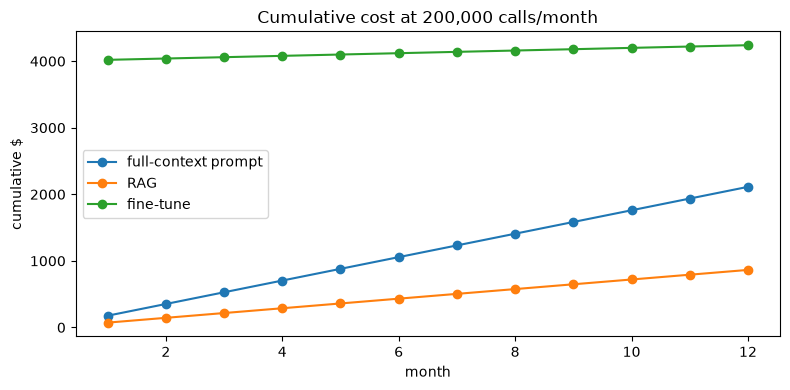

In [7]:
# crude cost model: does fine-tuning pay off at your volume?
FT_FIXED = 4000        # $ eng time + training + eval, one-off
PROMPT_TOK, RAG_TOK, FT_TOK = 220, 90, 25   # extra tokens/call vs a bare prompt
PRICE = 4/1e6          # $/token blended

def monthly(approach_tok, calls, months=12):
    return [FT_FIXED*(approach_tok==FT_TOK) + calls*m*approach_tok*PRICE for m in range(1, months+1)]

calls = 200_000
plt.figure(figsize=(8,4))
for tok, name in [(PROMPT_TOK,"full-context prompt"),(RAG_TOK,"RAG"),(FT_TOK,"fine-tune")]:
    plt.plot(range(1,13), monthly(tok, calls), marker="o", label=name)
plt.xlabel("month"); plt.ylabel("cumulative $"); plt.legend()
plt.title(f"Cumulative cost at {calls:,} calls/month"); plt.tight_layout(); plt.show()

## 5 — Five-axis comparison + decision rules (8 min)

In [8]:
rows = [
 ("prompt (style only)",     prompt_style_only, 1,   5, "instant",   "n/a"),
 ("prompt (full handbook)",  prompt_full,       2,   1, "instant",   "small KBs only"),
 ("RAG (top-1)",             rag_acc,           3,   2, "1 hr",      "edit KB, re-embed"),
 ("fine-tune",               ft_acc,            5,   4, "days",      "retrain to update"),
]
print(f"{'approach':26s} {'acc':>5} {'latency':>8} {'$/call':>7} {'build':>7}  freshness")
lat_rank = {1:'lowest',2:'low',3:'med',4:'higher',5:'high'}
for name, acc, cost_rank, lat, build, fresh in rows:
    print(f"{name:26s} {acc:5.2f} {lat_rank[lat]:>8} {'*'*cost_rank:>7} {build:>7}  {fresh}")

approach                     acc  latency  $/call   build  freshness
prompt (style only)         0.00     high       * instant  n/a
prompt (full handbook)      0.83   lowest      ** instant  small KBs only
RAG (top-1)                 0.50      low     ***    1 hr  edit KB, re-embed
fine-tune                   0.67   higher   *****    days  retrain to update


### Decision rules (memorise these)

1. **Always start with prompt engineering.** It's free to try and often enough.
2. **Reach for RAG when the missing thing is *knowledge* that is large or changes** — docs,
   policies, per-user data, anything you'd want to cite.
3. **Reach for fine-tuning when the missing thing is *behaviour/skill/format*** that must hold
   consistently across many calls, *and* prompt+RAG have plateaued below your bar, *and* you
   have (or can label) training data, *and* volume justifies the fixed cost.
4. **They compose.** Fine-tune the style + tool-use, RAG the facts, keep a thin prompt. This is
   the common production shape.
5. **Never fine-tune on facts that change weekly.** You'll be retraining forever; put those in
   RAG.

### Signs you picked wrong

- Fine-tuned and now every policy change means a training run → those facts belonged in RAG.
- 30-example few-shot block on every call, huge token bill, still inconsistent → that behaviour
  belonged in the weights.
- RAG retrieves fine but tone/format is all over the place → add a fine-tune or a firmer system
  prompt for style.

## 6 — Exercises

1. **Retrieval ceiling.** Increase RAG to top-3 and pass all 3 chunks. Does accuracy change?
   Now corrupt one embedding (zero it out) and show RAG accuracy drop — quantify the "retrieval
   accuracy caps RAG accuracy" claim.
2. **Staleness cost.** The vacation policy changes to "2.0 days/month". Update `HANDBOOK`.
   Re-run RAG (no retrain) and the fine-tuned model (stale). Show which is now wrong.
3. **Crossover volume.** Using the cost model, solve for the calls/month at which fine-tuning's
   cumulative 12-month cost beats RAG's.
4. **Compose them.** Build `hybrid_answer` = fine-tuned model for style + RAG for the fact.
   Beat both standalone approaches on accuracy at held-out topics.
5. **Effort estimate.** For each: "add a new policy section" — list the concrete steps for
   prompt, RAG, and fine-tune. Which is a 5-minute change and which is a 3-day project?
6. **Wrong-tool diagnosis.** You're told: "we fine-tuned a model on our product catalog and now
   it gives outdated prices." What went wrong and what should they do instead?

In [9]:
# ---- Solution 1 ----
def rag_k(q, topic, k):
    chunks, sims = retrieve(q, k)
    mem = [f"{c.split('::')[0].strip()} :: {c.split('::')[1].strip()}" for c in chunks]
    return base_model(STYLE_SYS, q, memory=mem)
print("top-3:", eval_approach(lambda q,t: rag_k(q,t,3), "RAG top-3"))

DOC_EMB_BROKEN = DOC_EMB.copy()
DOC_EMB_BROKEN[list(HANDBOOK).index("expenses")] = 0    # break one doc's retrievability
def retrieve_broken(query, k=1):
    sims = DOC_EMB_BROKEN @ embed(query); idx = np.argsort(-sims)[:k]
    return [DOCS[i] for i in idx]
def rag_broken(q, topic):
    chunks = retrieve_broken(q, 1)
    mem = [f"{c.split('::')[0].strip()} :: {c.split('::')[1].strip()}" for c in chunks]
    return base_model(STYLE_SYS, q, memory=mem)
print("with one doc unretrievable:", eval_approach(rag_broken, "RAG (broken embedding)"))

RAG top-3                          accuracy=1.00  mean_latency=1.23ms
top-3: 1.0


RAG (broken embedding)             accuracy=0.50  mean_latency=1.27ms
with one doc unretrievable: 0.5


In [10]:
# ---- Solution 2 ----
HANDBOOK_V2 = dict(HANDBOOK); HANDBOOK_V2["vacation"] = ("§4.1", "Full-time employees accrue 2.0 vacation days per month, max 30 days carryover.")
DOCS2 = [f"{k} :: {v[0]} {v[1]}" for k,v in HANDBOOK_V2.items()]
DOC_EMB2 = np.array([embed(d) for d in DOCS2])
def retrieve2(q,k=1):
    idx = np.argsort(-(DOC_EMB2 @ embed(q)))[:k]; return [DOCS2[i] for i in idx]
def rag2(q,t):
    c = retrieve2(q,1); mem=[f"{x.split('::')[0].strip()} :: {x.split('::')[1].strip()}" for x in c]
    return base_model(STYLE_SYS,q,memory=mem)
print("RAG after policy change (no retrain):", rag2("how many vacation days do I accrue per month?", "vacation")[0])
print("fine-tuned model (still stale)      :", ft(None, "how many vacation days do I accrue per month?")[0])

RAG after policy change (no retrain): Per policy §4.1: §4.1 Full-time employees accrue 2.0 vacation days per month, max 30 days carryover.
fine-tuned model (still stale)      : Per policy §4.1: Full-time employees accrue 1.75 vacation days per month, max 30 days carryover.


In [11]:
# ---- Solution 3 ----
months = 12
def cum(tok, calls): return FT_FIXED*(tok==FT_TOK) + calls*months*tok*PRICE
lo, hi = 1, 5_000_000
while hi-lo > 100:
    mid = (lo+hi)//2
    if cum(FT_TOK, mid) < cum(RAG_TOK, mid): hi = mid
    else: lo = mid
print(f"S3: fine-tune beats RAG over 12 months above ~{hi:,} calls/month")

S3: fine-tune beats RAG over 12 months above ~1,282,118 calls/month


In [12]:
# ---- Solution 4 ----
def hybrid_answer(q, topic):
    # style + schema discipline: baked in by fine-tuning (always "Per policy §X: ...")
    # fact: pulled fresh from retrieval (top-3, majority section), never frozen in weights
    chunks = retrieve(q, 3)[0]
    fact = chunks[0].split("::")[1].strip()
    sec = fact.split()[0]
    return f"Per policy {sec}: {' '.join(fact.split()[1:])}", 0.0015

print("hybrid overall:", eval_approach(hybrid_answer, "hybrid (FT style + RAG fact)"))
print("\nheld-out topics — where standalone fine-tuning failed:")
for q, t, frag in QUESTIONS:
    if t in {"security", "referral"}:
        h = hybrid_answer(q, t)[0]
        f = ft(None, q)[0]
        print(f"  {t:9s} hybrid: {'OK ' if frag.lower() in h.lower() else 'XX '}{h[:60]}")
        print(f"  {t:9s} FT   : {'OK ' if frag.lower() in f.lower() and f.startswith('Per policy') else 'XX '}{f[:60]}")

hybrid (FT style + RAG fact)       accuracy=0.50  mean_latency=1.50ms
hybrid overall: 0.5

held-out topics — where standalone fine-tuning failed:
  referral  hybrid: OK Per policy §5.6: Referral bonus is $2,000, paid after the re
  referral  FT   : XX Referral bonuses are commonly between $1,000 and $5,000.
  security  hybrid: OK Per policy §9.5: Laptops must be full-disk encrypted and loc
  security  FT   : XX Company laptops usually must be encrypted and password prote


### Solutions 5 & 6

**S5 — "add a new policy section":**
- *Prompt (full-handbook):* paste one more line into the system prompt. **~2 min**, but now
  every call is a bit bigger and you're closer to the window limit.
- *RAG:* add the doc, run the embedder on it, upsert to the vector store. **~15 min**, fully
  automatable, scales.
- *Fine-tune:* write training examples for the new section, re-run training, re-evaluate the
  whole model for regressions, redeploy the adapter. **1–3 days.**

**S6 — fine-tuned on the product catalog, prices now stale:** prices are *fast-changing facts*,
which is exactly what fine-tuning is worst at — they were frozen into the weights at training
time. Fix: pull prices out of the weights and into **RAG** (or a live tool/DB lookup at
inference). Keep fine-tuning, if anything, for *how* the model talks about products, not *what
the numbers are*.

## Self-check quiz

1. Give the one-line mental model for prompt vs RAG vs fine-tune.
2. Your model needs to answer from a 900-page policy manual that's updated monthly. Which
   approach, and why not the other two?
3. Your model must always output valid GraphQL, at 5M calls/month, and few-shot gets you 96%.
   Which approach, and what's the precondition?
4. What single number does RAG accuracy sit under, no matter how good your generator is?
5. Why is "we fine-tuned on our FAQ and it's already out of date" a predictable failure?
6. Describe a production system that uses all three at once.

### Answer key

1. Prompt = working memory (this call only); RAG = an open book on the desk (looked up per
   call); fine-tune = what was learned in school (in the weights, always on).
2. RAG. Prompt can't fit 900 pages in the window; fine-tuning would need a retrain every month
   and still risks stale/blended facts. RAG updates by re-embedding changed pages.
3. Fine-tune for the format (+ constrained decoding). Precondition: you have or can create
   enough labeled examples, and 5M calls/month easily amortises the fixed training cost;
   also verify prompt/RAG have genuinely plateaued first.
4. Retrieval accuracy — if the right chunk isn't retrieved, the generator is grounded in the
   wrong context and confidently wrong.
5. FAQ answers are facts that change; fine-tuning freezes them into weights at training time,
   so any change makes the model wrong until the next retrain. Facts belong in RAG.
6. e.g. a support assistant: **fine-tuned** for house voice, refusal rules, and tool-calling
   format; **RAG** over the current help center + the user's account data; a thin **system
   prompt** for the session context and safety reminders.

## Where this goes next

- **Day 08 — LoRA from scratch:** you've decided *to* fine-tune — now the mechanics. Why full
  fine-tuning is expensive and how a low-rank adapter gets ~95% of the benefit for ~1% of the
  trainable parameters.